In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from open_clip import create_model_from_pretrained

In [2]:
# ----------------------------------------
# CONFIGURATION
# ----------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths to real images (200 each)
REAL_MILD_DIR   = "/data/liangz2/image_quality/real_images/mild"
REAL_SEVERE_DIR = "/data/liangz2/image_quality/real_images/severe"

# Paths to synthetic images (12 sets)
SYNTH_DIRS = {
    "SD21_i2i_mild":    "/data/liangz2/image_quality/fake_images/sd21/sd21_i2i_mild",
    "SD21_i2i_severe":  "/data/liangz2/image_quality/fake_images/sd21/sd21_i2i_severe",
    "SD21_t2i_mild":    "/data/liangz2/image_quality/fake_images/sd21/sd21_t2i_mild",
    "SD21_t2i_severe":  "/data/liangz2/image_quality/fake_images/sd21/sd21_t2i_severe",
    "SD35_i2i_mild":    "/data/liangz2/image_quality/fake_images/sd35/sd35_i2i_mild",
    "SD35_i2i_severe":  "/data/liangz2/image_quality/fake_images/sd35/sd35_i2i_severe",
    "SD35_t2i_mild":    "/data/liangz2/image_quality/fake_images/sd35/sd35_t2i_mild",
    "SD35_t2i_severe":  "/data/liangz2/image_quality/fake_images/sd35/sd35_t2i_severe",
    "StyleGAN2_mild":   "/data/liangz2/image_quality/fake_images/stylegan2/mild",
    "StyleGAN2_severe": "/data/liangz2/image_quality/fake_images/stylegan2/severe",
    "StyleGAN3_mild":   "/data/liangz2/image_quality/fake_images/stylegan3/mild",
    "StyleGAN3_severe": "/data/liangz2/image_quality/fake_images/stylegan3/severe",
}

# Pre‐tuned model and its weights
MODEL_NAME = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
SAVE_PATH  = "./biomedclip_model/biomedclip_visual_finetuned.pth"

# Output folder for plots and CSV
OUTPUT_DIR = "/data/liangz2/biomedclip_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
# ----------------------------------------
# 1. Load fine‐tuned BiomedCLIP vision encoder + processor
# ----------------------------------------
vision_model, processor = create_model_from_pretrained(
    MODEL_NAME,
    return_transform=True
)
vision_model.visual.load_state_dict(torch.load(SAVE_PATH, map_location="cpu"))
vision_model = vision_model.to(DEVICE).eval()

In [4]:
# ----------------------------------------
# 2. Helper: batch‐compute embeddings
# ----------------------------------------
def load_embeddings(folder: str, batch_size: int = 32):
    """
    Compute BiomedCLIP embeddings for every image in `folder`.
    Returns:
      - embs (NumPy array of shape [N, D])
      - paths (list of length N)
    """
    filenames = sorted([
        fn for fn in os.listdir(folder)
        if fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff"))
    ])
    paths = [os.path.join(folder, fn) for fn in filenames]
    all_embs = []

    for i in tqdm(range(0, len(paths), batch_size), desc=f"Embedding {os.path.basename(folder)}"):
        batch_paths = paths[i : i + batch_size]
        imgs = [Image.open(p).convert("RGB") for p in batch_paths]
        pix = torch.stack([processor(img) for img in imgs], dim=0).to(DEVICE)  # (B,3,224,224)
        with torch.no_grad():
            feats = vision_model.encode_image(pix)  # (B, D)
            feats = F.normalize(feats, dim=-1)      # unit‐normalize each
        all_embs.append(feats.cpu().numpy())

    all_embs = np.concatenate(all_embs, axis=0)  # (N, D)
    return all_embs, paths

In [5]:
# ----------------------------------------
# 3. Embed real images and normalize
# ----------------------------------------
real_mild_embs, _   = load_embeddings(REAL_MILD_DIR)    # (200, D)
real_severe_embs, _ = load_embeddings(REAL_SEVERE_DIR)  # (200, D)

real_mild_tensor   = torch.from_numpy(real_mild_embs).to(DEVICE)
real_severe_tensor = torch.from_numpy(real_severe_embs).to(DEVICE)

real_mild_tensor   = F.normalize(real_mild_tensor,   dim=-1)  # (200, D)
real_severe_tensor = F.normalize(real_severe_tensor, dim=-1)  # (200, D)

Embedding severe: 100%|██████████| 7/7 [00:02<00:00,  3.48it/s]


In [6]:
# ----------------------------------------
# 4. Embed synthetic sets and normalize
# ----------------------------------------
synth_emb_dict = {}
for name, folder in SYNTH_DIRS.items():
    embs, _ = load_embeddings(folder)
    tensor = torch.from_numpy(embs).to(DEVICE)
    tensor = F.normalize(tensor, dim=-1)  # (N_synth, D)
    synth_emb_dict[name] = tensor

Embedding severe: 100%|██████████| 32/32 [00:10<00:00,  3.20it/s]


In [10]:
# ----------------------------------------
# 5. Compute “consistency” = cosine similarity to each group’s own centroid
# ----------------------------------------
records = []

# 5a) Real‐mild group
with torch.no_grad():
    centroid_rm = F.normalize(real_mild_tensor.mean(dim=0, keepdim=True), dim=-1)  # (1, D)
    sims_rm = (real_mild_tensor @ centroid_rm.T).squeeze(1).cpu().numpy()          # (200,)
for sim in sims_rm:
    records.append({
        "CosSim":   sim,
        "Group":    "Real_mild",
        "Severity": "mild",
        "Generator":"Real"
    })

# 5b) Real‐severe group
with torch.no_grad():
    centroid_rs = F.normalize(real_severe_tensor.mean(dim=0, keepdim=True), dim=-1)  # (1, D)
    sims_rs = (real_severe_tensor @ centroid_rs.T).squeeze(1).cpu().numpy()         # (200,)
for sim in sims_rs:
    records.append({
        "CosSim":   sim,
        "Group":    "Real_severe",
        "Severity": "severe",
        "Generator":"Real"
    })

# 5c) Each synthetic group
for name, tensor in synth_emb_dict.items():
    severity = "mild" if name.endswith("_mild") else "severe"
    centroid = centroid_rm if severity == "mild" else centroid_rs

    with torch.no_grad():
        sims = (tensor @ centroid.T).squeeze(1).cpu().numpy()  # (N_synth,)

    gen_type = name.rsplit("_", 1)[0]  # e.g. "SD21_i2i" or "StyleGAN2"
    for sim in sims:
        records.append({
            "CosSim":   sim,
            "Group":    name,       # exact key like "SD21_i2i_mild"
            "Severity": severity,   # "mild" or "severe"
            "Generator": gen_type   # e.g. "SD21_i2i"
        })

df_all = pd.DataFrame.from_records(records)

In [11]:
# ----------------------------------------
# 6. Descriptive statistics per Generator × Severity
# ----------------------------------------
desc_stats = df_all.groupby(["Generator", "Severity"])["CosSim"].agg(
    mean="mean",
    std="std",
    minimum="min",
    maximum="max"
).reset_index()
desc_stats["range"] = desc_stats["maximum"] - desc_stats["minimum"]

desc_csv = os.path.join(OUTPUT_DIR, "consistency_descriptive_stats.csv")
desc_stats.to_csv(desc_csv, index=False)
print("Descriptive stats saved to:", desc_csv)
print(desc_stats)

Descriptive stats saved to: /data/liangz2/biomedclip_model/consistency_descriptive_stats.csv
    Generator Severity      mean       std   minimum   maximum     range
0        Real     mild  0.882101  0.082012  0.453773  0.966266  0.512493
1        Real   severe  0.870461  0.068816  0.506281  0.959318  0.453036
2    SD21_i2i     mild  0.847591  0.060607  0.611149  0.949228  0.338080
3    SD21_i2i   severe  0.386657  0.165307 -0.013698  0.877567  0.891264
4    SD21_t2i     mild  0.875960  0.039198  0.611748  0.948656  0.336908
5    SD21_t2i   severe  0.423921  0.111583  0.170943  0.763462  0.592519
6    SD35_i2i     mild  0.776149  0.079478  0.437094  0.939808  0.502715
7    SD35_i2i   severe  0.117576  0.099880 -0.155708  0.471355  0.627064
8    SD35_t2i     mild  0.787054  0.070258  0.529177  0.930926  0.401749
9    SD35_t2i   severe  0.166748  0.097387 -0.112210  0.512759  0.624968
10  StyleGAN2     mild  0.593365  0.284037 -0.019862  0.965727  0.985589
11  StyleGAN2   severe  0.53584

In [12]:
# ----------------------------------------
# 7. One‐way ANOVA (within each Severity) to test differences in mean consistency
# ----------------------------------------
anova_results = []
for sev in ["mild", "severe"]:
    subset = df_all[df_all["Severity"] == sev]
    generators = subset["Generator"].unique()
    arrays = [subset[subset["Generator"] == g]["CosSim"].values for g in generators]
    F_stat, p_value = f_oneway(*arrays)
    anova_results.append({
        "Severity": sev,
        "F_stat":   F_stat,
        "p_value":  p_value
    })

anova_df = pd.DataFrame.from_records(anova_results)
anova_csv = os.path.join(OUTPUT_DIR, "consistency_anova.csv")
anova_df.to_csv(anova_csv, index=False)
print("\nANOVA results saved to:", anova_csv)
print(anova_df)


ANOVA results saved to: /data/liangz2/biomedclip_model/consistency_anova.csv
  Severity      F_stat  p_value
0     mild  406.160065      0.0
1   severe  828.446106      0.0


/tmp/ipykernel_2279784/2328886171.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2279784/2328886171.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2279784/2328886171.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2279784/2328886171.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")


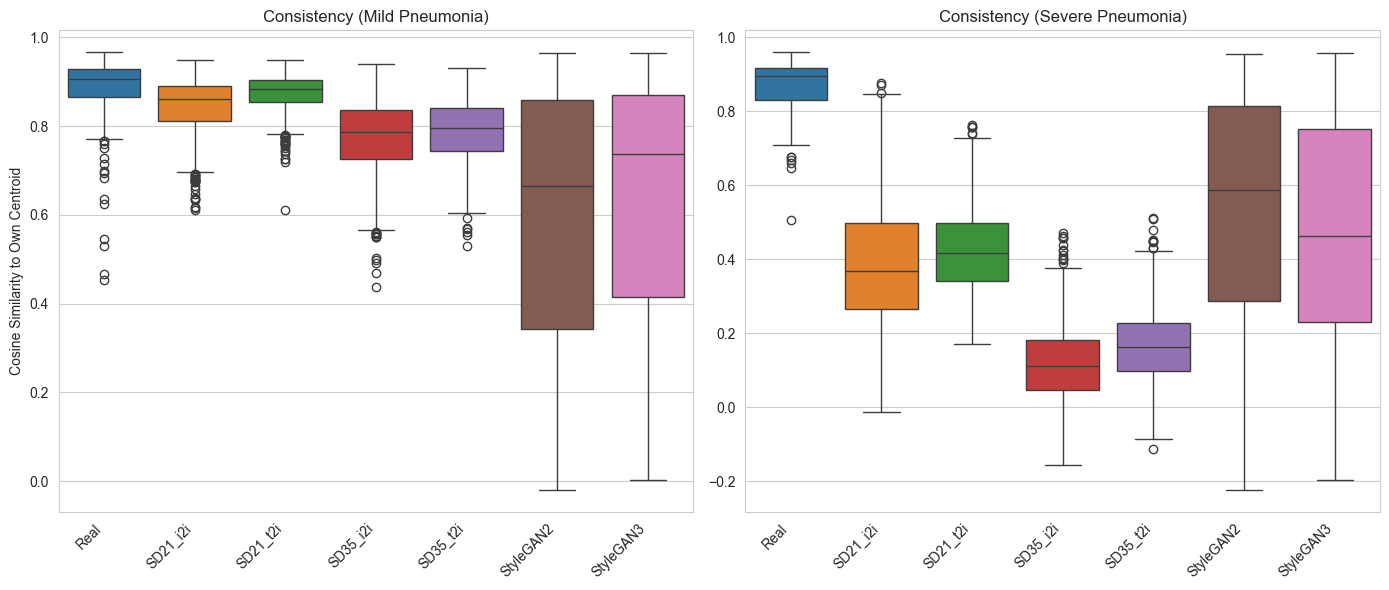

Boxplots saved to: /data/liangz2/biomedclip_model/consistency_boxplots.png


In [15]:
# ----------------------------------------
# 8. Box plots (CosSim distributions) for mild vs. severe
# ----------------------------------------
# ----------------------------------------
# 8. Box plots (CosSim distributions) for mild vs. severe
# ----------------------------------------
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# 8a) Mild pneumonia
ax1 = plt.subplot(1, 2, 1)
sns.boxplot(
    data=df_all[df_all["Severity"] == "mild"],
    x="Generator",
    y="CosSim",
    palette="tab10",
    ax=ax1
)
ax1.set_title("Consistency (Mild Pneumonia)")
ax1.set_xlabel("")  # remove the "Generator" label
ax1.set_ylabel("Cosine Similarity to Own Centroid")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# 8b) Severe pneumonia
ax2 = plt.subplot(1, 2, 2)
sns.boxplot(
    data=df_all[df_all["Severity"] == "severe"],
    x="Generator",
    y="CosSim",
    palette="tab10",
    ax=ax2
)
ax2.set_title("Consistency (Severe Pneumonia)")
ax2.set_xlabel("")  # remove the "Generator" label
ax2.set_ylabel("")  # shared with ax1
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "consistency_boxplots.png")
plt.savefig(plot_path, dpi=300)
plt.show()
print("Boxplots saved to:", plot_path)